**SCENARIO 1 – ASSOCIATION RULE MINING USING APRIORI ALGORITHM**

Problem Statement
Identify frequent itemsets and generate association rules from transactional data using the Apriori algorithm.

Dataset (Kaggle – Public)
Market Basket Dataset / Grocery Dataset
Example: https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset
(Any transactional dataset can be used)

Target Variable: Association rules (frequent item relationships)
Input Feature:
• Transaction ID
• Items purchased

IN-LAB TASKS
1.	Import required Python libraries (Pandas, mlxtend, etc.)
2.	Load transactional dataset
3.	Perform data preprocessing (convert to one-hot encoding format)
4.	Generate frequent itemsets using Apriori algorithm
5.	Set minimum support threshold
6.	Generate association rules
7.	Filter rules using confidence and lift
8.	Interpret rules

Evaluation Metrics
• Support
• Confidence
• Lift

Analysis Tasks
• Observe effect of support threshold on itemsets
• Identify strong association rules
• Compare rules with different confidence levels
• Analyze real-world meaning of rules





Visualization
• Bar chart of frequent itemsets
• Network graph of association rules
• Support vs confidence plots


Dataset Dimensions: (14963, 167)
   Instant food products  UHT-milk  abrasive cleaner  artif. sweetener  \
0                  False     False             False             False   
1                  False     False             False             False   
2                  False     False             False             False   
3                  False     False             False             False   
4                  False     False             False             False   

   baby cosmetics   bags  baking powder  bathroom cleaner   beef  berries  \
0           False  False          False             False  False    False   
1           False  False          False             False  False    False   
2           False  False          False             False  False    False   
3           False  False          False             False  False    False   
4           False  False          False             False  False    False   

   ...  turkey  vinegar  waffles  whipped/sour cream  whisk

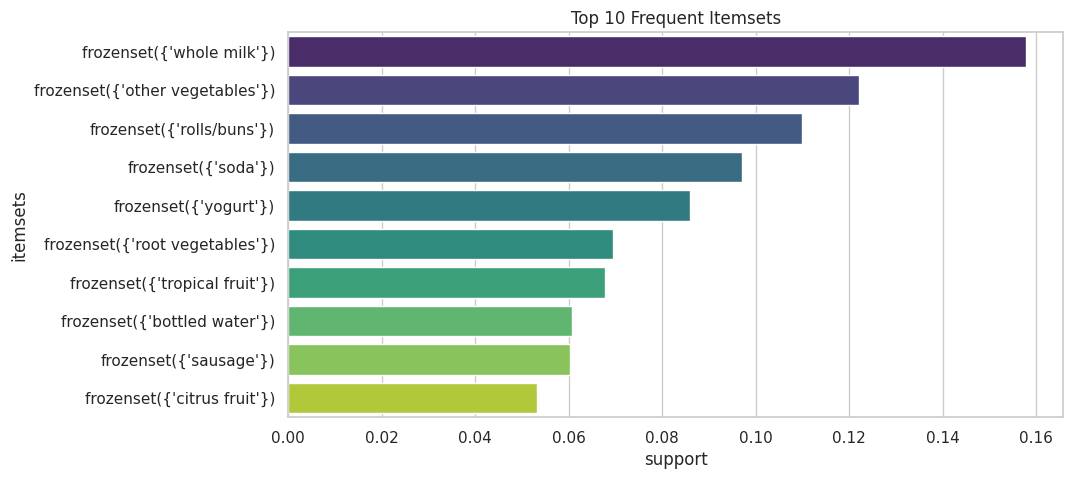

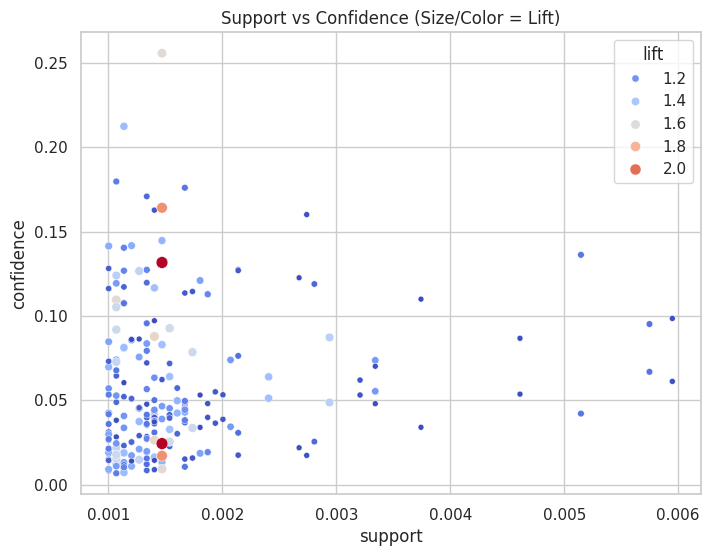

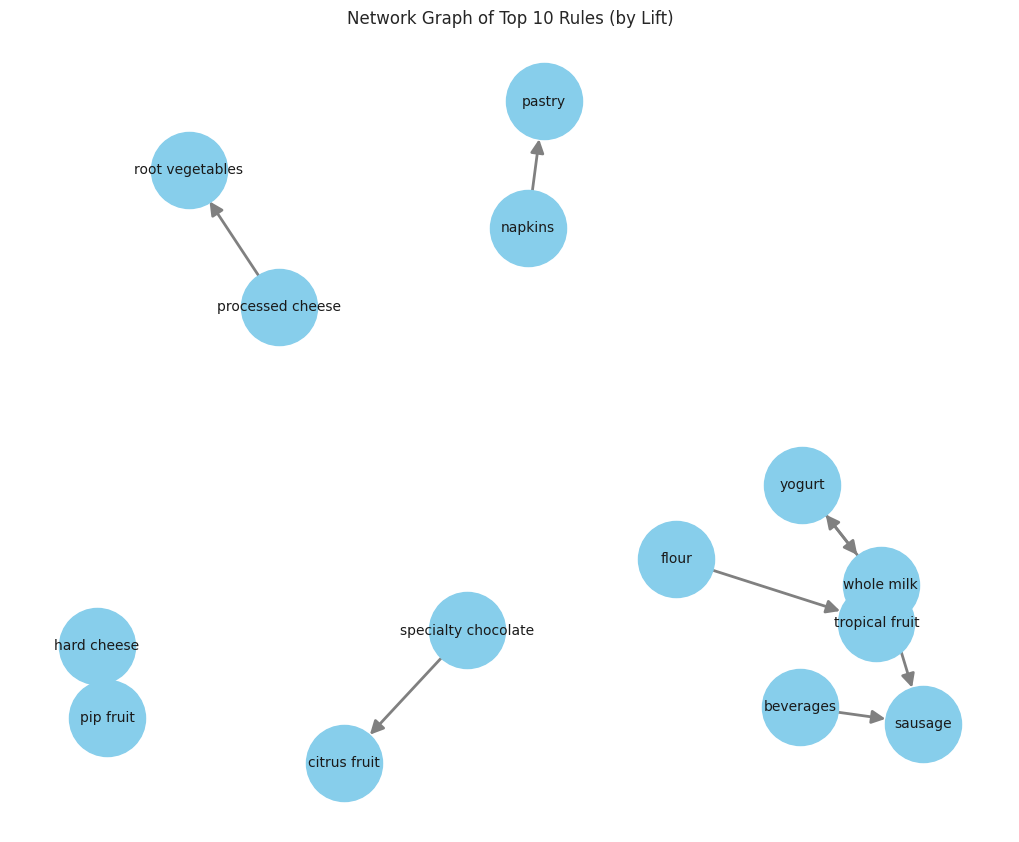

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_wine

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

df = pd.read_csv('/content/Groceries_dataset (2).csv')
df.head()

transactions = df.groupby(['Member_number', 'Date'])['itemDescription'].apply(list).values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_ary, columns=te.columns_)

print(f"Dataset Dimensions: {df_encoded.shape}")
print(df_encoded.head())

min_support = 0.001
frequent_itemsets = apriori(df_encoded, min_support=min_support, use_colnames=True)

rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.0)

filtered_rules = rules[rules['confidence'] > 0.05].sort_values(by='lift', ascending=False)

print(f"Total rules found: {len(rules)}")
print(f"Rules after filtering: {len(filtered_rules)}")

plt.figure(figsize=(10, 5))
top_itemsets = frequent_itemsets.sort_values(by='support', ascending=False).head(10)
sns.barplot(x='support', y='itemsets', data=top_itemsets, palette='viridis')
plt.title('Top 10 Frequent Itemsets')
plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(x='support', y='confidence', size='lift', data=rules, hue='lift', palette='coolwarm')
plt.title('Support vs Confidence (Size/Color = Lift)')
plt.grid(True)
plt.show()

import networkx as nx

def plot_network(rules_df, num_rules=10):
    G = nx.DiGraph()
    subset = rules_df.head(num_rules)

    for i, row in subset.iterrows():
        ant = list(row['antecedents'])[0]
        con = list(row['consequents'])[0]
        G.add_edge(ant, con, weight=row['lift'])

    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, k=0.5)
    nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=3000,
            edge_color='gray', font_size=10, width=2, arrowsize=20)
    plt.title(f'Network Graph of Top {num_rules} Rules (by Lift)')
    plt.show()

plot_network(filtered_rules)

**SCENARIO 2 – DIMENSIONALITY REDUCTION USING PCA**

Problem Statement
Reduce high-dimensional data into lower dimensions while preserving maximum variance using PCA.

Dataset (Same / Alternative Dataset)
Any dataset with multiple numerical features
Example: Iris Dataset / Wine Dataset

Target Variable: Principal components (reduced feature set)
Input Features
• Numerical features (e.g., measurements, attributes)

IN-LAB TASKS
1.	Load dataset
2.	Perform data preprocessing (handling missing values, scaling)
3.	Standardize features
4.	Apply Principal Component Analysis (PCA)
5.	Compute principal components
6.	Determine explained variance ratio
7.	Reduce dimensions (e.g., 2D or 3D)
8.	Visualize transformed data

Evaluation Metrics
• Explained Variance Ratio
• Cumulative Variance

Analysis Tasks
• Analyze variance captured by each component
• Decide optimal number of components
• Compare original vs reduced data
• Observe effect on visualization

Visualization
• Scree plot (variance vs components)
• 2D/3D scatter plot of principal components
• Cumulative variance graph


VETTRISELVAN D - 24BAD127

Explained Variance Ratio:
[0.39542486 0.17836259 0.10329102 0.06627984 0.06267875 0.0480556
 0.03955707 0.02500244 0.02103871 0.01873615 0.01613203 0.01205691
 0.00925458 0.00412945]

Cumulative Variance:
[0.39542486 0.57378745 0.67707846 0.74335831 0.80603706 0.85409266
 0.89364973 0.91865217 0.93969088 0.95842703 0.97455906 0.98661596
 0.99587055 1.        ]


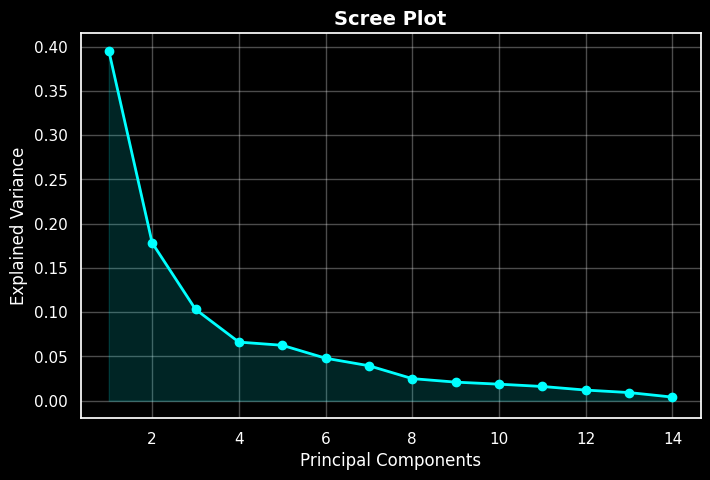

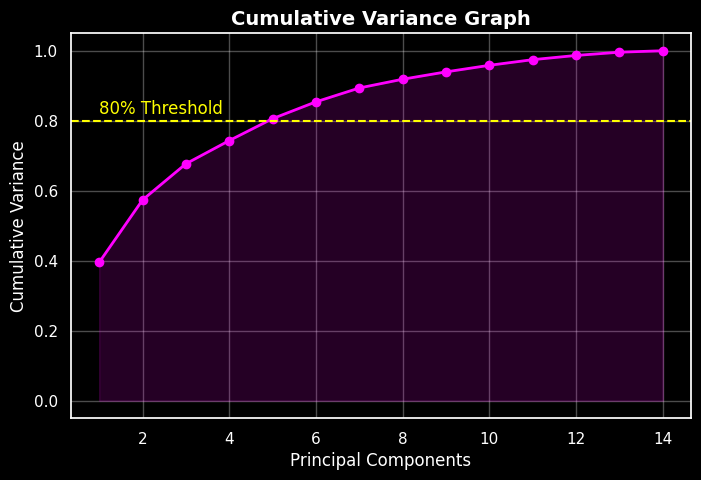

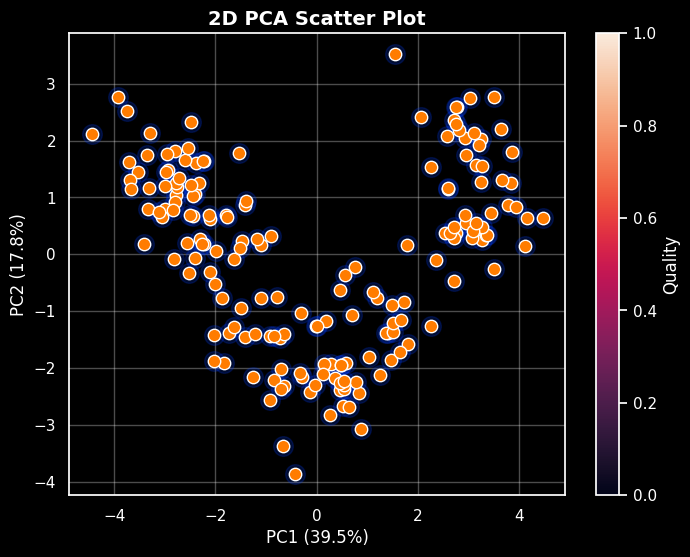

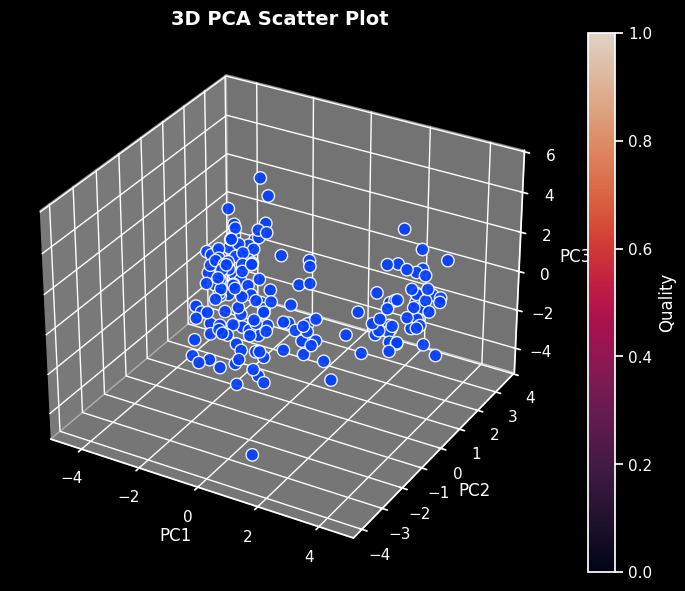

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
import warnings

warnings.filterwarnings('ignore')

# Premium theme
plt.style.use('dark_background')
sns.set_palette("bright")

print("VETTRISELVAN D - 24BAD127")

# Load dataset
data = pd.read_csv('/content/wine.csv')

# Select numerical columns
data = data.select_dtypes(include=['float64', 'int64'])

# Handle missing values
data = data.dropna()

# Features & target
X = data.drop(columns=['quality'], errors='ignore')
y = data['quality'] if 'quality' in data.columns else None

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = explained_variance.cumsum()

print("\nExplained Variance Ratio:")
print(explained_variance)

print("\nCumulative Variance:")
print(cumulative_variance)

# =========================
# SCREE PLOT (Neon Style)
# =========================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained_variance)+1),
         explained_variance,
         marker='o',
         linewidth=2,
         color='#00FFFF')

plt.fill_between(range(1, len(explained_variance)+1),
                 explained_variance,
                 color='#00FFFF',
                 alpha=0.15)

plt.title("Scree Plot", fontsize=14, fontweight='bold')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.grid(alpha=0.3)
plt.show()

# =========================
# CUMULATIVE VARIANCE
# =========================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance)+1),
         cumulative_variance,
         marker='o',
         linewidth=2,
         color='#FF00FF')

plt.fill_between(range(1, len(cumulative_variance)+1),
                 cumulative_variance,
                 color='#FF00FF',
                 alpha=0.15)

plt.axhline(y=0.80, color='yellow', linestyle='--', linewidth=1.5)
plt.text(1, 0.82, "80% Threshold", color='yellow')

plt.title("Cumulative Variance Graph", fontsize=14, fontweight='bold')
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance")
plt.grid(alpha=0.3)
plt.show()

# =========================
# 2D PCA SCATTER (Glow Effect)
# =========================
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))

# Glow layer
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
            c=y, cmap='cool',
            s=200, alpha=0.2)

# Main points
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=y, cmap='cool',
                      s=80, edgecolor='white')

plt.title("2D PCA Scatter Plot", fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')

plt.colorbar(scatter, label='Quality')
plt.grid(alpha=0.3)
plt.show()

# =========================
# 3D PCA SCATTER (Neon Style)
# =========================
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=y,
    cmap='plasma',
    s=80,
    edgecolor='white',
    alpha=0.9
)

ax.set_title("3D PCA Scatter Plot", fontsize=14, fontweight='bold')
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

fig.colorbar(scatter, label='Quality')
plt.show()